In [2]:
import pandas as pd
import numpy as np

print("Environment is ready!")

Environment is ready!


In [3]:
%pip install pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 19.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 KB 19.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 24.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 29.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 KB 12.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 KB 15.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
print(pd.__version__)

2.3.3


In [4]:
# Load all three SQL exports from your Data folder
df_games = pd.read_csv("/home/grant/Desktop/Personal Project /Data/steam_games_cleaned.csv")
df_price_tiers = pd.read_csv("/home/grant/Desktop/Personal Project /Data/price_tier_summary.csv")
df_genres = pd.read_csv("/home/grant/Desktop/Personal Project /Data/genre_summary.csv")

# Quick verification
print("Games Shape:", df_games.shape)
print("Price Tiers Shape:", df_price_tiers.shape)
print("Genres Shape:", df_genres.shape)

Games Shape: (48759, 13)
Price Tiers Shape: (5, 7)
Genres Shape: (28, 5)


In [5]:
# 1. Skewness check (built directly into pandas)
print("--- Metric Skewness ---")
print(df_games[['price', 'positive_pct', 'avg_hours_played', 'peak_ccu']].skew())

# 2. Linear (Pearson) Correlation
print("\n--- Pearson Correlation ---")
display(df_games[['price', 'positive_pct', 'avg_hours_played', 'peak_ccu']].corr(method='pearson'))

# 3. Rank-Order (Spearman) Correlation
print("\n--- Spearman Correlation ---")
display(df_games[['price', 'positive_pct', 'avg_hours_played', 'peak_ccu']].corr(method='spearman'))






--- Metric Skewness ---
price                6.169623
positive_pct        -1.093637
avg_hours_played    83.235950
peak_ccu            64.889476
dtype: float64

--- Pearson Correlation ---


,price,positive_pct,avg_hours_played,peak_ccu
price,1.000000,0.008853,0.043125,0.085377
positive_pct,0.008853,1.000000,0.019021,0.023543
avg_hours_played,0.043125,0.019021,1.000000,0.036021
peak_ccu,0.085377,0.023543,0.036021,1.000000



--- Spearman Correlation ---


,price,positive_pct,avg_hours_played,peak_ccu
price,1.000000,0.053967,0.308116,0.418306
positive_pct,0.053967,1.000000,0.106921,0.165501
avg_hours_played,0.308116,0.106921,1.000000,0.441693
peak_ccu,0.418306,0.165501,0.441693,1.000000


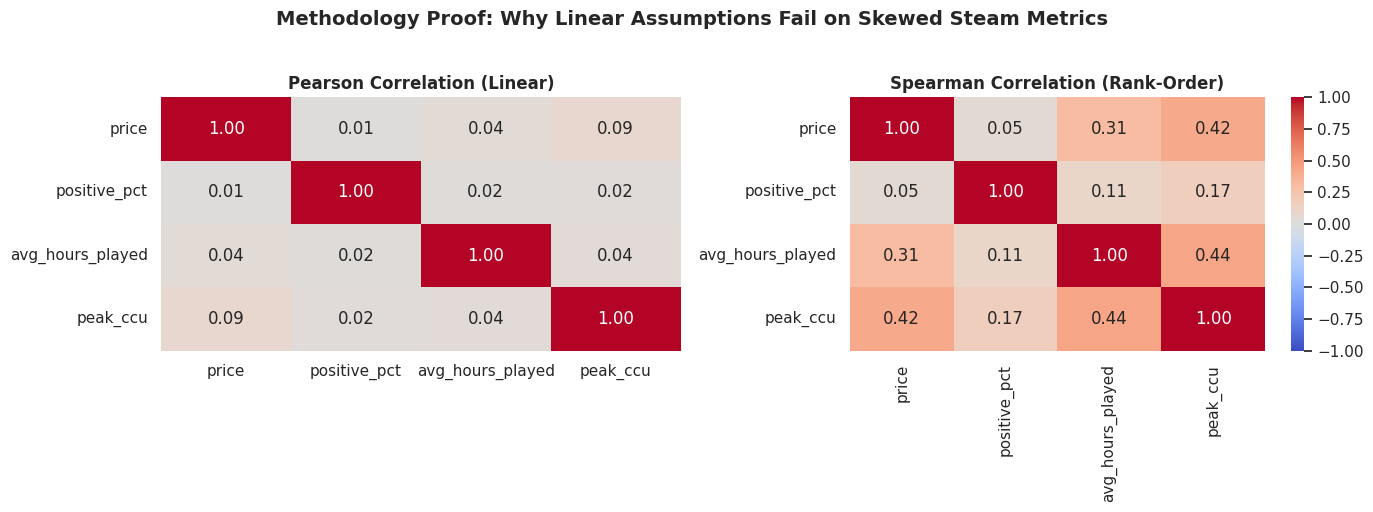

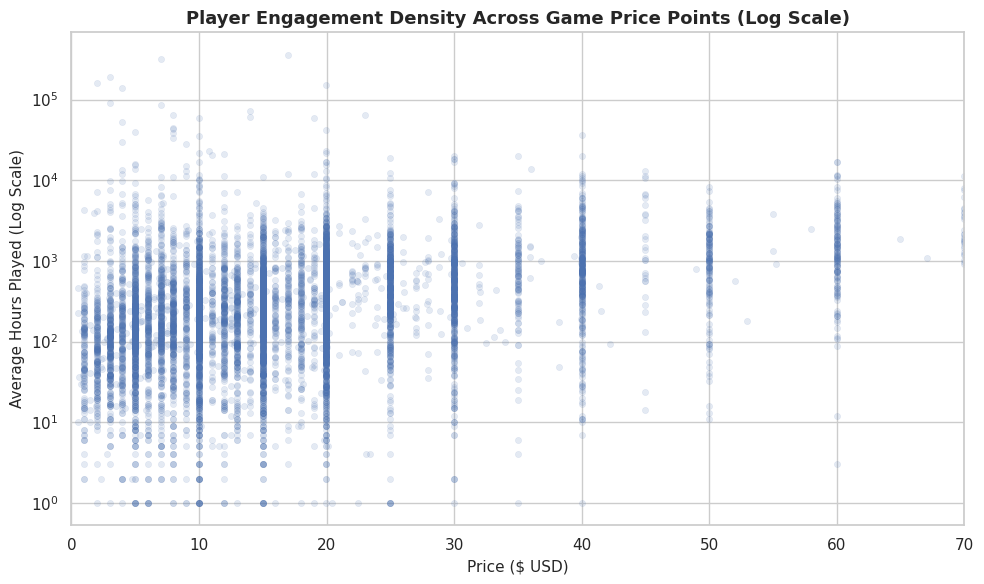

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set style for a clean, professional aesthetic
sns.set_theme(style="whitegrid")

# ==========================================
# CHART 1: Dual Heatmap (Pearson vs Spearman)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Select continuous metrics for correlation
cols = ["price", "positive_pct", "avg_hours_played", "peak_ccu"]

# Pearson Heatmap
sns.heatmap(
    df_games[cols].corr(method="pearson"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=axes[0],
    cbar=False,
)
axes[0].set_title("Pearson Correlation (Linear)", fontsize=12, fontweight="bold")

# Spearman Heatmap
sns.heatmap(
    df_games[cols].corr(method="spearman"),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    ax=axes[1],
)
axes[1].set_title(
    "Spearman Correlation (Rank-Order)", fontsize=12, fontweight="bold"
)

plt.suptitle(
    "Methodology Proof: Why Linear Assumptions Fail on Skewed Steam Metrics",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig('Methodology Proof.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# CHART 2: Log-Transformed Scatter Plot
# ==========================================
plt.figure(figsize=(10, 6))

# Filter out zero values so log-scale doesn't crash log10(0)
df_scatter = df_games[
    (df_games["price"] > 0) & (df_games["avg_hours_played"] > 0)
].copy()

# Plot scatter with log scale on Y-axis
sns.scatterplot(
    data=df_scatter,
    x="price",
    y="avg_hours_played",
    alpha=0.15,
    s=20,
    edgecolor=None,
)

plt.yscale("log")  # Logarithmic scale to handle extreme right-skew
plt.title(
    "Player Engagement Density Across Game Price Points (Log Scale)",
    fontsize=13,
    fontweight="bold",
)
plt.xlabel("Price ($ USD)", fontsize=11)
plt.ylabel("Average Hours Played (Log Scale)", fontsize=11)
plt.xlim(0, 70)  # Focus on mainstream pricing boundaries ($0-$70)

plt.tight_layout()
plt.savefig('Player Engagement Density.png', dpi=300, bbox_inches='tight')
plt.show()


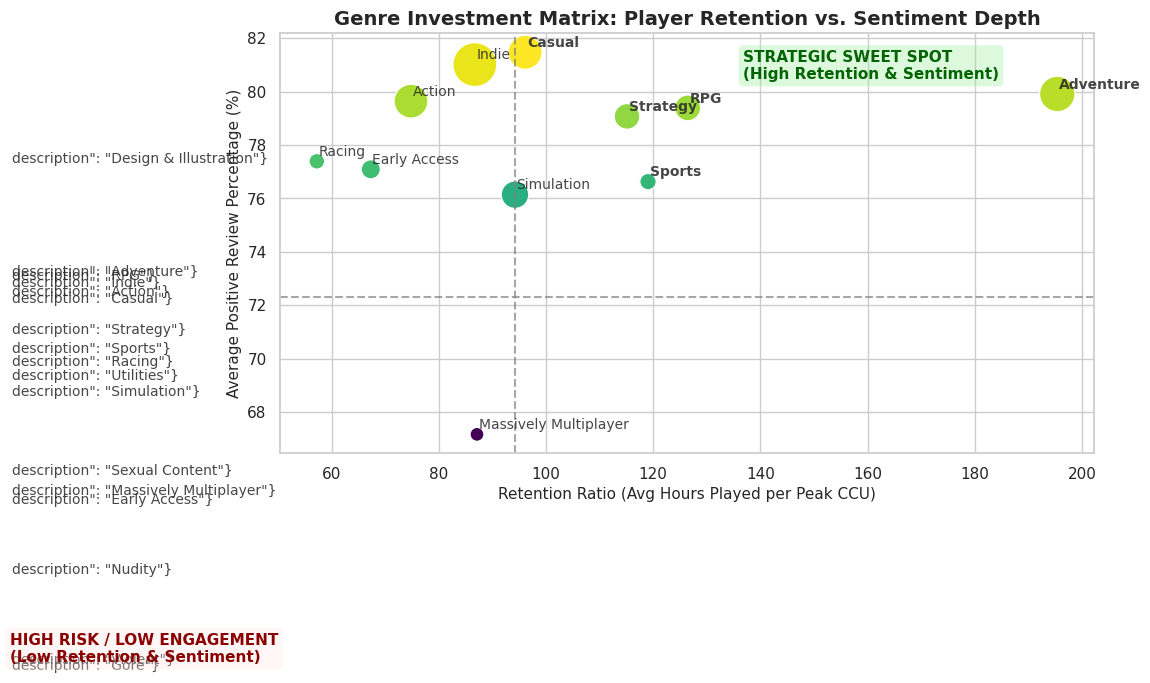

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set clean aesthetic style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 8))

# 1. Scatter plot of genres
scatter = sns.scatterplot(
    data=df_genres_clean,
    x="retention_ratio",
    y="avg_positive_pct",
    size="total_games",  # Size points by total games in genre
    sizes=(100, 1000),
    hue="avg_positive_pct",
    palette="viridis",
    legend=False,
)

# 2. Quadrant median dividers
median_retention = df_genres_clean["retention_ratio"].median()
median_sentiment = df_genres["avg_positive_pct"].median()

plt.axvline(
    x=median_retention,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label="Median Retention",
)
plt.axhline(
    y=median_sentiment,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label="Median Sentiment",
)

# 3. Label each genre directly on the chart
for idx, row in df_genres.iterrows():
    plt.text(
        row["retention_ratio"] + 0.3,
        row["avg_positive_pct"] + 0.2,
        row["clean_genre"],
        fontsize=10,
        fontweight=(
            "bold" if row["retention_ratio"] > median_retention else "normal"
        ),
        alpha=0.85,
    )

# 4. Add executive quadrant callouts
plt.text(
    df_genres["retention_ratio"].max() * 0.70,
    df_genres["avg_positive_pct"].max() - 1,
    "STRATEGIC SWEET SPOT\n(High Retention & Sentiment)",
    fontsize=11,
    fontweight="bold",
    color="darkgreen",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.3),
)

plt.text(
    df_genres["retention_ratio"].min(),
    df_genres["avg_positive_pct"].min() + 0.5,
    "HIGH RISK / LOW ENGAGEMENT\n(Low Retention & Sentiment)",
    fontsize=11,
    fontweight="bold",
    color="darkred",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="mistyrose", alpha=0.3),
)

# Formatting
plt.title(
    "Genre Investment Matrix: Player Retention vs. Sentiment Depth",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Retention Ratio (Avg Hours Played per Peak CCU)", fontsize=11)
plt.ylabel("Average Positive Review Percentage (%)", fontsize=11)

plt.tight_layout()
plt.show()

In [11]:
df_genres_clean = df_genres[
    (~df_genres["clean_genre"].str.contains("description", na=False))
    & (df_genres["retention_ratio"] > 0)
].copy()

print(f"Cleaned genres count: {len(df_genres_clean)}")

Cleaned genres count: 11


In [13]:
# Filter out raw string artifacts, dictionary remnants, and zero-retention rows
df_genres_clean = df_genres[
    (~df_genres["clean_genre"].str.contains("description|:", na=False))
    & (df_genres["retention_ratio"] > 0)
].copy()

print(f"Cleaned genres remaining: {len(df_genres_clean)}")

Cleaned genres remaining: 11


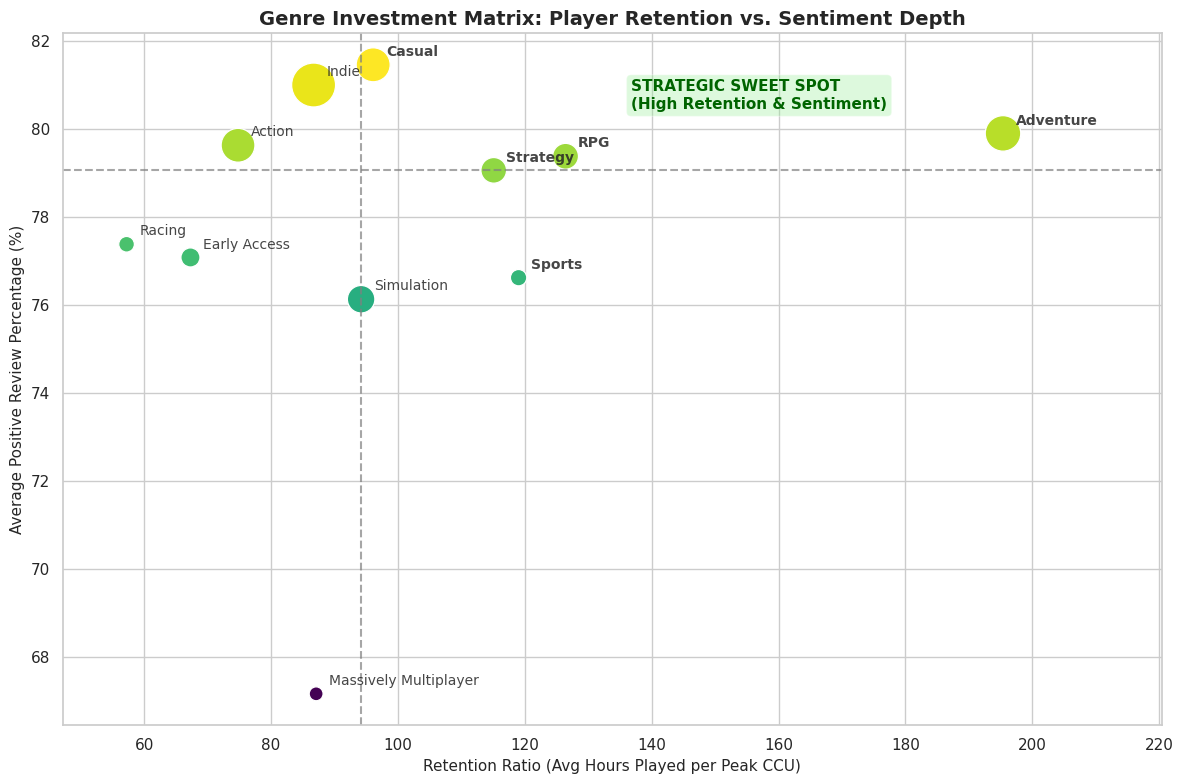

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# 1. Strictly filter out any string artifacts
df_genres_clean = df_genres[
    (df_genres["retention_ratio"] > 10)  # Drops all the 0-retention artifacts
    & (~df_genres["clean_genre"].str.contains("description|\{|:", na=False))
].copy()

# 2. Plot scatter using ONLY the clean dataset
scatter = sns.scatterplot(
    data=df_genres_clean,
    x="retention_ratio",
    y="avg_positive_pct",
    size="total_games",
    sizes=(100, 1000),
    hue="avg_positive_pct",
    palette="viridis",
    legend=False,
)

# 3. Quadrant median dividers
median_retention = df_genres_clean["retention_ratio"].median()
median_sentiment = df_genres_clean["avg_positive_pct"].median()

plt.axvline(
    x=median_retention,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label="Median Retention",
)
plt.axhline(
    y=median_sentiment,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label="Median Sentiment",
)

# 4. Strictly loop over df_genres_clean to place labels
for idx, row in df_genres_clean.iterrows():
    genre_name = str(row["clean_genre"]).strip()

    # Skip any leftover long JSON string
    if len(genre_name) > 25:
        continue

    plt.text(
        row["retention_ratio"] + 2,
        row["avg_positive_pct"] + 0.2,
        genre_name,
        fontsize=10,
        fontweight=(
            "bold" if row["retention_ratio"] > median_retention else "normal"
        ),
        alpha=0.85,
    )

# 5. Executive quadrant callouts
plt.text(
    df_genres_clean["retention_ratio"].max() * 0.70,
    df_genres_clean["avg_positive_pct"].max() - 1,
    "STRATEGIC SWEET SPOT\n(High Retention & Sentiment)",
    fontsize=11,
    fontweight="bold",
    color="darkgreen",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen", alpha=0.3),
)

plt.title(
    "Genre Investment Matrix: Player Retention vs. Sentiment Depth",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Retention Ratio (Avg Hours Played per Peak CCU)", fontsize=11)
plt.ylabel("Average Positive Review Percentage (%)", fontsize=11)

# Set explicit X boundaries so nothing off-screen displays
plt.xlim(
    df_genres_clean["retention_ratio"].min() - 10,
    df_genres_clean["retention_ratio"].max() + 25,
)

plt.tight_layout()
plt.savefig('genre_matrix_plot.png', dpi=300, bbox_inches='tight')
plt.show()


In [16]:
import os

os.makedirs("../data/processed", exist_ok=True)

df_games.to_csv("../data/processed/steam_games_processed.csv", index=False)
df_price_tiers.to_csv("../data/processed/price_tier_summary.csv", index=False)
df_genres_clean.to_csv("../data/processed/genre_summary.csv", index=False)

print("All processed datasets saved successfully!")

All processed datasets saved successfully!
